# 01 — Nettoyage des données | Data Cleaning

**Projet :** Segmentation de clientèle (RFM + K-means)
**Données :** [Online Retail II — UCI](https://archive.ics.uci.edu/dataset/502/online+retail+ii) — transactions d'un détaillant en ligne britannique, déc. 2009 à déc. 2011.

**Objectif de ce notebook :** passer des transactions brutes à un jeu de données propre, où chaque ligne est un achat réel fait par un client identifié. Chaque étape de nettoyage est journalisée pour savoir exactement combien de lignes on perd, et pourquoi.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
DATA_DIR = Path("../data")

## 1. Chargement

Le fichier Excel contient deux feuilles (une par année). La lecture d'un fichier `.xlsx` de cette taille prend une à deux minutes : on la fait **une seule fois**, puis on sauvegarde une copie CSV beaucoup plus rapide à relire.

In [2]:
raw_csv = DATA_DIR / "online_retail_II_raw.csv"

if raw_csv.exists():
    df_raw = pd.read_csv(raw_csv, dtype={"Invoice": str, "StockCode": str},
                         parse_dates=["InvoiceDate"])
else:
    sheets = pd.read_excel(DATA_DIR / "online_retail_II.xlsx", sheet_name=None,
                           dtype={"Invoice": str, "StockCode": str})
    df_raw = pd.concat(sheets.values(), ignore_index=True)
    df_raw.to_csv(raw_csv, index=False)

print(df_raw.shape)
df_raw.head()

(1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 2. Premier coup d'œil

In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  str           
 1   StockCode    1067371 non-null  str           
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(1), str(3)
memory usage: 65.1+ MB


In [4]:
# Valeurs manquantes par colonne
df_raw.isna().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [5]:
# Statistiques : on cherche les anomalies (quantités ou prix négatifs, extrêmes)
df_raw[["Quantity", "Price"]].describe()

,Quantity,Price
count,1.067371e+06,1.067371e+06
mean,9.938898e+00,4.649388e+00
std,1.727058e+02,1.235531e+02
min,-8.099500e+04,-5.359436e+04
25%,1.000000e+00,1.250000e+00
50%,3.000000e+00,2.100000e+00
75%,1.000000e+01,4.150000e+00
max,8.099500e+04,3.897000e+04


## 3. Nettoyage, étape par étape

La fonction `log_step` enregistre le nombre de lignes avant et après chaque filtre. Ce tableau servira directement dans la section *Défis rencontrés* du README.

In [6]:
log = []

def log_step(df_before, df_after, etape, raison):
    log.append({
        "Étape": etape,
        "Raison": raison,
        "Lignes avant": len(df_before),
        "Lignes retirées": len(df_before) - len(df_after),
        "Lignes après": len(df_after),
    })
    return df_after

df = df_raw.copy()

**3.1 Doublons exacts.** Des lignes identiques en tous points (probablement des erreurs d'enregistrement).

In [7]:
df = log_step(df, df.drop_duplicates(), "Doublons", "Lignes identiques en tous points")

**3.2 Clients non identifiés.** Sans `Customer ID`, impossible de rattacher un achat à une personne, donc impossible de segmenter. C'est la plus grosse perte, et c'est normal : on regarde d'abord quelle part des ventes elle représente.

In [8]:
sans_id = df["Customer ID"].isna()
print(f"Lignes sans client : {sans_id.mean():.1%}")

df = log_step(df, df[~sans_id], "Clients manquants", "Customer ID absent — achat non rattachable")

Lignes sans client : 22.8%


**3.3 Annulations et retours.** Les factures qui commencent par `C` sont des annulations, avec une quantité négative. On les retire pour ne garder que les achats.

In [9]:
annulation = df["Invoice"].str.startswith("C") | (df["Quantity"] <= 0)
df = log_step(df, df[~annulation], "Annulations / retours", "Facture 'C…' ou quantité ≤ 0")

**3.4 Prix nuls.** Un prix de 0 correspond à des échantillons, cadeaux ou ajustements d'inventaire, pas à des ventes.

In [10]:
df = log_step(df, df[df["Price"] > 0], "Prix nul", "Prix ≤ 0 — pas une vente")

**3.5 Codes non-produits.** Les vrais produits ont un `StockCode` qui commence par 5 chiffres (ex. `85123A`). Les autres codes sont des frais : `POST` (livraison), `M` (manuel), `BANK CHARGES`, `AMAZONFEE`, etc.

In [11]:
est_produit = df["StockCode"].str.match(r"^\d{5}")
print("Codes retirés :", sorted(df.loc[~est_produit, "StockCode"].unique()))

df = log_step(df, df[est_produit], "Codes non-produits", "Frais de port, ajustements, frais bancaires")

Codes retirés : ['ADJUST', 'ADJUST2', 'BANK CHARGES', 'C2', 'D', 'DOT', 'M', 'PADS', 'POST', 'SP1002', 'TEST001', 'TEST002']


## 4. Bilan du nettoyage

In [12]:
bilan = pd.DataFrame(log)
bilan

,Étape,Raison,Lignes avant,Lignes retirées,Lignes après
0,Doublons,Lignes identiques en tous points,1067371,34335,1033036
1,Clients manquants,Customer ID absent — achat non rattachable,1033036,235151,797885
2,Annulations / retours,Facture 'C…' ou quantité ≤ 0,797885,18390,779495
3,Prix nul,Prix ≤ 0 — pas une vente,779495,70,779425
4,Codes non-produits,"Frais de port, ajustements, frais bancaires",779425,2848,776577


In [13]:
print(f"Conservé : {len(df) / len(df_raw):.1%} des lignes d'origine")

Conservé : 72.8% des lignes d'origine


## 5. Préparation pour l'analyse RFM

On ajoute le montant de chaque ligne et on convertit l'identifiant client en entier (il est lu comme décimal à cause des valeurs manquantes d'origine).

In [14]:
df["Customer ID"] = df["Customer ID"].astype(int)
df["Total"] = df["Quantity"] * df["Price"]

print(f"Clients uniques : {df['Customer ID'].nunique():,}")
print(f"Factures : {df['Invoice'].nunique():,}")
print(f"Période : {df['InvoiceDate'].min():%Y-%m-%d} → {df['InvoiceDate'].max():%Y-%m-%d}")

Clients uniques : 5,852
Factures : 36,594
Période : 2009-12-01 → 2011-12-09


## 6. Exploration rapide

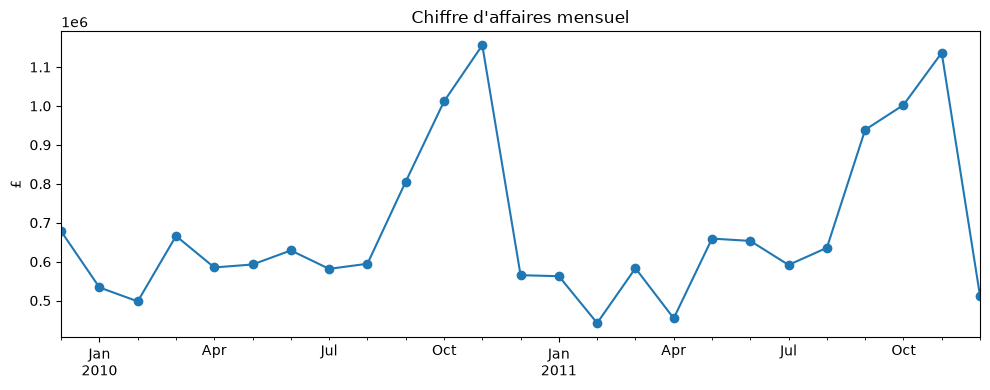

In [15]:
ventes_mois = df.set_index("InvoiceDate")["Total"].resample("MS").sum()

fig, ax = plt.subplots(figsize=(10, 4))
ventes_mois.plot(ax=ax, marker="o")
ax.set_title("Chiffre d'affaires mensuel")
ax.set_ylabel("£")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

À observer : la saisonnalité (pic avant Noël) et le dernier mois, qui semble chuter uniquement parce que les données s'arrêtent le 9 décembre 2011. On en tiendra compte pour la **récence** dans le notebook suivant.

In [16]:
(df.groupby("Country")["Customer ID"].nunique()
   .sort_values(ascending=False).head(10)
   .rename("Clients"))

Country
United Kingdom    5334
Germany            107
France              93
Spain               38
Belgium             29
Portugal            23
Switzerland         22
Netherlands         22
Sweden              19
Italy               17
Name: Clients, dtype: int64

## 7. Sauvegarde

In [17]:
df.to_csv(DATA_DIR / "online_retail_clean.csv", index=False)
print("Sauvegardé :", DATA_DIR / "online_retail_clean.csv")

Sauvegardé : ..\data\online_retail_clean.csv


## Prochaine étape

`02_rfm.ipynb` : calculer, pour chaque client, la **Récence**, la **Fréquence** et le **Montant**.